# Question 2: Barabási-Albert Scale-Free Network

Implementing the BA algorithm from scratch. New nodes attach preferentially to existing high-degree nodes:

$$P_i(k) \propto \frac{k_i}{\sum_j k_j}$$

This produces a power-law degree distribution.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
def barabasi_albert_manual(n, m0, m):
    """
    n  = total nodes
    m0 = initial fully connected nodes
    m  = edges added per new node
    """

    G = nx.Graph()

    # Step 1: Create initial complete graph
    for i in range(m0):
        for j in range(i+1, m0):
            G.add_edge(i, j)

    # Step 2: Add new nodes with preferential attachment
    for new_node in range(m0, n):
        degrees = np.array([G.degree(node) for node in G.nodes()])
        total_degree = degrees.sum()

        # Probability distribution
        probs = degrees / total_degree

        existing_nodes = list(G.nodes())

        # Choose m unique nodes based on degree probability
        targets = set()
        while len(targets) < m:
            chosen = np.random.choice(existing_nodes, p=probs)
            targets.add(chosen)

        for t in targets:
            G.add_edge(new_node, t)

    return G

# Parameters
n = 200     # nodes per network
m0 = 5      # initial clique size
m = 3       # edges per new node

# Quick test
G_test = barabasi_albert_manual(n, m0, m)
print(f"Single instance: {G_test.number_of_nodes()} nodes, {G_test.number_of_edges()} edges")
print(f"Average degree: {2 * G_test.number_of_edges() / G_test.number_of_nodes():.2f}")

## Generating 100 Instances

We generate 100 BA networks with the same parameters and compute:
- (a) Average clustering coefficient
- (b) Characteristic path length
- (c) Degree distribution

All metrics are averaged across instances.

In [3]:
# ============================================================
# Generate 100 instances and collect metrics
# ============================================================
NUM_INSTANCES = 100

all_clustering_coeffs = []
all_path_lengths = []
all_degrees = []  # pooled degrees across all instances for distribution

print(f"Generating {NUM_INSTANCES} BA networks (n={n}, m0={m0}, m={m})...\n")

for i in range(NUM_INSTANCES):
    G = barabasi_albert_manual(n, m0, m)
    
    # (a) Clustering coefficient
    C = nx.average_clustering(G)
    all_clustering_coeffs.append(C)
    
    # (b) Characteristic path length
    if nx.is_connected(G):
        L = nx.average_shortest_path_length(G)
    else:
        Gcc = G.subgraph(max(nx.connected_components(G), key=len))
        L = nx.average_shortest_path_length(Gcc)
    all_path_lengths.append(L)
    
    # (c) Degrees for distribution
    degrees = [G.degree(node) for node in G.nodes()]
    all_degrees.extend(degrees)
    
    if (i + 1) % 20 == 0:
        print(f"  Instance {i+1}/{NUM_INSTANCES} done — CC={C:.4f}, L={L:.4f}")

print(f"\nAll {NUM_INSTANCES} instances generated successfully.")

Generating 100 BA networks (n=200, m0=5, m=3)...

  Instance 20/100 done — CC=0.1101, L=2.8566
  Instance 40/100 done — CC=0.1302, L=2.8451
  Instance 60/100 done — CC=0.1012, L=2.8434
  Instance 80/100 done — CC=0.1234, L=2.7966
  Instance 100/100 done — CC=0.0957, L=2.8755

All 100 instances generated successfully.


---

## (a) Average Clustering Coefficient (over 100 instances)

Average Clustering Coefficient over 100 instances:
  Mean:  0.104755
  Std:   0.017764


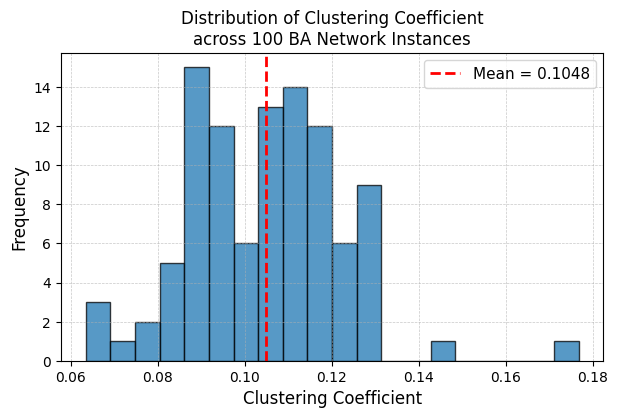

Figure saved: clustering_coefficient_distribution.png


In [4]:
avg_cc = np.mean(all_clustering_coeffs)
std_cc = np.std(all_clustering_coeffs)

print(f"Average Clustering Coefficient over {NUM_INSTANCES} instances:")
print(f"  Mean:  {avg_cc:.6f}")
print(f"  Std:   {std_cc:.6f}")

# Plot distribution of clustering coefficients across instances
plt.figure(figsize=(7, 4))
plt.hist(all_clustering_coeffs, bins=20, alpha=0.75, color='#1f77b4', edgecolor='black')
plt.axvline(avg_cc, color='red', linestyle='--', linewidth=2, label=f'Mean = {avg_cc:.4f}')
plt.xlabel('Clustering Coefficient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Clustering Coefficient\nacross {NUM_INSTANCES} BA Network Instances', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig('clustering_coefficient_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: clustering_coefficient_distribution.png")

---

## (b) Characteristic Path Length (over 100 instances)

Characteristic Path Length over 100 instances:
  Mean:  2.854654
  Std:   0.038409


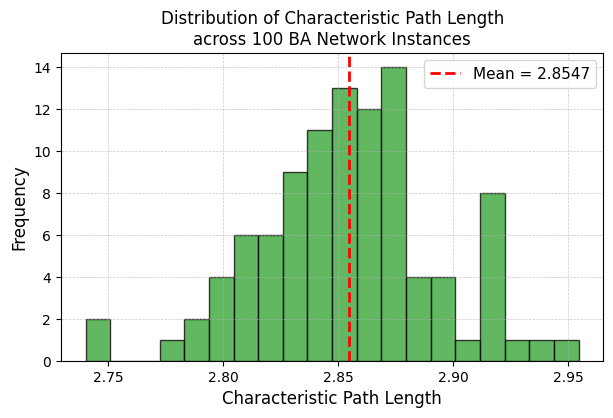

Figure saved: path_length_distribution.png


In [5]:
avg_L = np.mean(all_path_lengths)
std_L = np.std(all_path_lengths)

print(f"Characteristic Path Length over {NUM_INSTANCES} instances:")
print(f"  Mean:  {avg_L:.6f}")
print(f"  Std:   {std_L:.6f}")

# Plot distribution of path lengths across instances
plt.figure(figsize=(7, 4))
plt.hist(all_path_lengths, bins=20, alpha=0.75, color='#2ca02c', edgecolor='black')
plt.axvline(avg_L, color='red', linestyle='--', linewidth=2, label=f'Mean = {avg_L:.4f}')
plt.xlabel('Characteristic Path Length', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of Characteristic Path Length\nacross {NUM_INSTANCES} BA Network Instances', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig('path_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: path_length_distribution.png")

## (c) Degree Distribution (pooled over 100 instances)

Pooling all node degrees from all 100 instances for a smoother P(k) estimate.

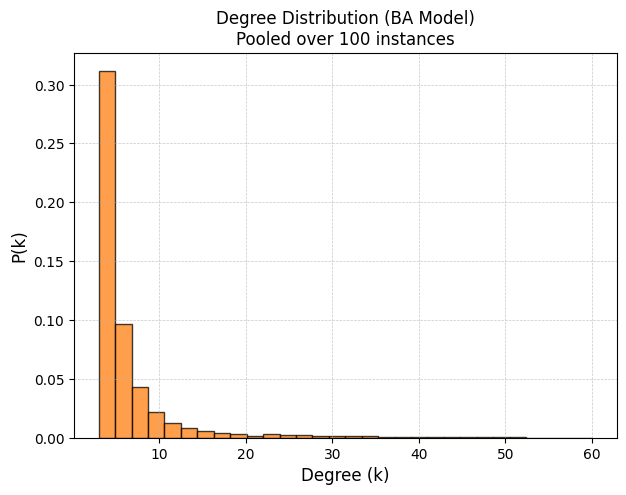

Figure saved: degree_distribution_histogram.png


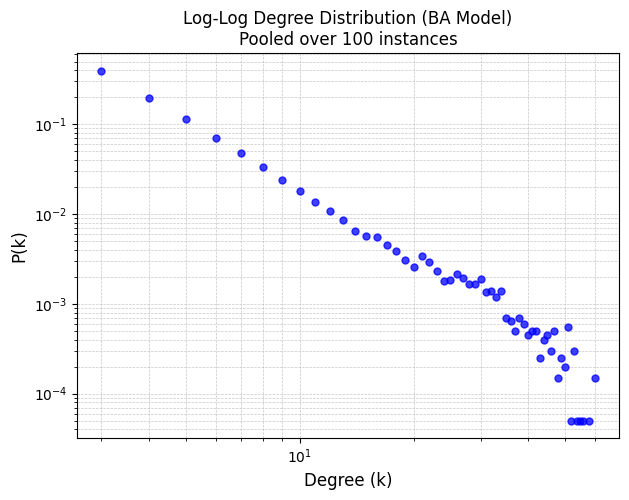

Figure saved: degree_distribution_loglog.png


In [6]:
# Histogram of degree distribution (pooled across 100 instances)
plt.figure(figsize=(7, 5))
plt.hist(all_degrees, bins=30, density=True, alpha=0.75, color='#ff7f0e', edgecolor='black')
plt.xlabel("Degree (k)", fontsize=12)
plt.ylabel("P(k)", fontsize=12)
plt.title(f"Degree Distribution (BA Model)\nPooled over {NUM_INSTANCES} instances", fontsize=12)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig('degree_distribution_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: degree_distribution_histogram.png")

# Log-Log plot of degree distribution
unique_deg, counts = np.unique(all_degrees, return_counts=True)
prob = counts / sum(counts)

plt.figure(figsize=(7, 5))
plt.loglog(unique_deg, prob, 'bo', markersize=5, alpha=0.75)
plt.xlabel("Degree (k)", fontsize=12)
plt.ylabel("P(k)", fontsize=12)
plt.title(f"Log-Log Degree Distribution (BA Model)\nPooled over {NUM_INSTANCES} instances", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig('degree_distribution_loglog.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: degree_distribution_loglog.png")

## Summary

Over 100 independent instances ($n=200$, $m_0=5$, $m=3$):

- **Mean clustering coefficient: 0.105** (±0.018). This is quite low, which is expected for the basic BA model — new nodes attach to hubs based on degree, not local structure, so triangles rarely form.
- **Mean characteristic path length: 2.855** (±0.038). Very short despite the sparse network — a result of the hub-and-spoke structure that keeps nodes within a few hops of each other.
- The log-log degree distribution is roughly linear, consistent with $P(k) \propto k^{-3}$. There are a handful of high-degree hubs and a long tail of low-degree nodes.
- Low clustering + short paths is the characteristic signature of the BA scale-free model.